# Notebook 13b, EN vs DE Input Comparison: Jaccard Similarity

**Core question:** Does giving LLMs German input improve agreement with pipeline NER
systems compared to English translations?

## Experimental design

| Condition | Input text | Entity output | Before Jaccard | Language issue |
|---|---|---|---|---|
| A, EN | `content_en` (English) | English | Back-translated EN→DE via OPUS-MT | acknowledged |
| B, DE | `content` (German original) | German | None, used directly | clean |
| Pipelines | `content` (German original) | German | None | clean |

**Why 8000 chars:** At 3000 chars LLMs could reach only 52% of pipeline entities by
position. At 8000 chars coverage is 96.6%.

**Condition B is the primary comparison.** Both LLM output and pipeline gold are in
German, no language mismatch.

**Condition A is a documented baseline.** EN entity strings are back-translated to
German via OPUS-MT before Jaccard comparison. This introduces a known limitation:

> **Methodological note, Condition A limitation**
> Back-translation of isolated entity strings is less reliable than translating full
> sentences because context is lost. Surface form mismatches will occur even after
> correct translation (e.g. LLM extracts "Supreme Court of Auditors", pipeline
> extracted "Oberste Rechnungshof", these refer to the same entity but will not
> match after back-translation). Condition A Jaccard scores are therefore a
> **conservative lower bound** on true EN-input LLM agreement, not a precise measure.
> Results are included for completeness and to quantify the translation cost, but
> Condition B is the methodologically valid comparison.

**DE prompt:** LLMs instructed to return entity text exactly as in source, no
translation to English.

In [1]:
# ── CELL 1 : INSTALLATION ────────────────────────────────────────────────────
!pip install -q groq huggingface_hub
!pip install -q easynmt
!pip install -q 'numpy>=2.0'
import nltk; nltk.download('punkt_tab', quiet=True)  # required by EasyNMT
!pip install -q sacremoses   # speeds up OPUS-MT tokenisation significantly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.3/142.3 kB 3.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.4/73.4 kB 3.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 84.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 34.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.5/897.5 kB 13.8 MB/s eta 0:00:00


In [2]:
# ── CELL 2 : IMPORTS & CONFIGURATION ─────────────────────────────────────────

import os, json, pickle, time, re
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from google.colab import drive, userdata

drive.mount('/content/drive', force_remount=False)

ROOT        = Path('/content/drive/MyDrive/thesis')
DATA_PROC   = ROOT / 'Project/Data/Processed'
FIGURES_DIR = ROOT / 'Project/Outputs/Figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

GROQ_TOKEN = userdata.get('GROQ_TOKEN')
HF_TOKEN   = userdata.get('HF_TOKEN')

# ── Text limit ────────────────────────────────────────────────────────────────
TEXT_LIMIT = 8000   # covers 96.6% of entities by position

# ── Checkpointing ─────────────────────────────────────────────────────────────
SAVE_EVERY               = 10
MAX_CONSECUTIVE_FAILURES = 5
MAX_FAILURE_RATE         = 0.20
GROQ_SLEEP = 35.0   # 35 seconds between calls — stays within 70B token limits

HF_SLEEP                 = 3.0
RETRY_DELAYS = [30, 60, 120]  # was [4, 8, 16] — 70B needs much longer waits
# ── Models ────────────────────────────────────────────────────────────────────
# Each model runs in both EN and DE conditions.
# provider: 'groq' or 'hf'
# Remove Qwen 7B, add Llama 4 Scout 17B
MODELS = {
    "llama-3.1-8b-instant"                     : {"scale_B": 8,  "family": "llama",  "provider": "groq"},
    "meta-llama/llama-4-scout-17b-16e-instruct": {"scale_B": 17, "family": "llama4", "provider": "groq"},
    "qwen/qwen3-32b"                           : {"scale_B": 32, "family": "qwen3",  "provider": "groq"},
    "llama-3.3-70b-versatile"                  : {"scale_B": 70, "family": "llama",  "provider": "groq"},
}

# Per-model sleep — 70B needs much longer gaps to avoid token rate limits
# 17B and 32B are moderate, 8B is fast
MODEL_SLEEP = {
    "llama-3.3-70b-versatile"                  : 35.0,
    "meta-llama/llama-4-scout-17b-16e-instruct": 4.0,
    "qwen/qwen3-32b"                           : 3.0,
    "llama-3.1-8b-instant"                     : 2.0,
}
CONDITIONS = ["en", "de"]

# ── HF providers to try for Qwen 7B (in order) ───────────────────────────────
HF_PROVIDERS = ["together", "novita", "sambanova", "nebius", "fireworks-ai"]

# ── Pipeline entity columns ───────────────────────────────────────────────────
PIPELINE_ENTITY_COLS = {
    "spaCy"  : "ner_spacy",
    "Stanza" : "ner_stanza",
    "Flair"  : "ner_flair",
}

# ── NER prompts ───────────────────────────────────────────────────────────────
NER_SYSTEM_PROMPT_EN = """You are a named entity recognition (NER) system.
Extract ALL named entities from the text provided.

Return ONLY a valid JSON object — no markdown, no explanation, no preamble:
{
  "entities": [
    {"text": "<entity surface form>", "label": "<TYPE>"}
  ]
}

Use exactly these four labels:
  PER   -- person names
  LOC   -- locations, countries, cities, geographical features
  ORG   -- organisations, companies, institutions
  MISC  -- other named entities (events, products, languages, nationalities, etc.)

If no entities are found return:  {"entities": []}"""

NER_SYSTEM_PROMPT_DE = """You are a named entity recognition (NER) system.
Extract ALL named entities from the German text provided.
CRITICAL: Return entity text EXACTLY as it appears in the German source — do NOT translate to English.
For example: use "Deutschland" not "Germany", "München" not "Munich", "Bundesregierung" not "Federal Government".

Return ONLY a valid JSON object — no markdown, no explanation, no preamble:
{
  "entities": [
    {"text": "<entity text exactly as in source>", "label": "<TYPE>"}
  ]
}

Use exactly these four labels:
  PER   -- person names
  LOC   -- locations, countries, cities, geographical features
  ORG   -- organisations, companies, institutions
  MISC  -- other named entities (events, products, languages, nationalities, etc.)

If no entities are found return:  {"entities": []}"""

NER_USER_TEMPLATE = "Extract named entities from the following text:\n\n{text}"

print("✓ Configuration loaded")
print(f"  Groq token : {'SET' if GROQ_TOKEN else '⚠ MISSING'}")
print(f"  HF token   : {'SET' if HF_TOKEN else '⚠ MISSING (Qwen 7B will be skipped)'}")
print(f"  Text limit : {TEXT_LIMIT} chars")
print(f"  Models     : {list(MODELS.keys())}")
print(f"  Conditions : {CONDITIONS}")
print(f"  Total runs : {len(MODELS) * len(CONDITIONS)}")


Mounted at /content/drive
✓ Configuration loaded
  Groq token : SET
  HF token   : SET
  Text limit : 8000 chars
  Models     : ['llama-3.1-8b-instant', 'meta-llama/llama-4-scout-17b-16e-instruct', 'qwen/qwen3-32b', 'llama-3.3-70b-versatile']
  Conditions : ['en', 'de']
  Total runs : 8


In [3]:
# ── CELL 3 : CHECK AVAILABLE GROQ MODELS ─────────────────────────────────────

from groq import Groq
groq_client = Groq(api_key=GROQ_TOKEN)

print("Querying Groq...")
try:
    available_groq = {m.id for m in groq_client.models.list().data}
    print(f"  {len(available_groq)} models available")
except Exception as e:
    available_groq = set()
    print(f"  ⚠ Could not list: {e}")

for model_id, meta in MODELS.items():
    if meta["provider"] != "groq":
        continue
    status = "✓" if model_id in available_groq else "✗ NOT FOUND"
    print(f"  {status} {model_id} ({meta['scale_B']}B)")

print("\nQwen 7B → HF Inference API (provider availability checked at runtime)")


Querying Groq...
  16 models available
  ✓ llama-3.1-8b-instant (8B)
  ✓ meta-llama/llama-4-scout-17b-16e-instruct (17B)
  ✓ qwen/qwen3-32b (32B)
  ✓ llama-3.3-70b-versatile (70B)

Qwen 7B → HF Inference API (provider availability checked at runtime)


In [4]:
# ── CELL 4 : LOAD EXISTING DATA ──────────────────────────────────────────────

print("Loading pipeline results...")
pipeline_df = pd.read_pickle(DATA_PROC / 'ner_pipeline_results.pkl')
print(f"  shape   : {pipeline_df.shape}")

# Verify columns
for name, col in PIPELINE_ENTITY_COLS.items():
    ok = "✓" if col in pipeline_df.columns else "⚠ MISSING"
    print(f"  {ok} {name}: '{col}'")
for col in ['content', 'content_en', 'article_id']:
    ok = "✓" if col in pipeline_df.columns else "⚠ MISSING"
    print(f"  {ok} column '{col}'")

# ── Article IDs — from Qwen 7B checkpoint (183 articles, same as all prev work) ──
qwen7b_ckpt_path = DATA_PROC / 'ner_llm_checkpoint.pkl'
if qwen7b_ckpt_path.exists():
    with open(qwen7b_ckpt_path, 'rb') as f:
        qwen7b_old = pickle.load(f)
    # Old format: flat dict {article_id: {status, entities}}
    ARTICLE_IDS_183 = [
        aid for aid, data in qwen7b_old.items()
        if isinstance(data, dict) and data.get('status') != 'api_error'
    ]
    print(f"\n  Working set: {len(ARTICLE_IDS_183)} articles (from Qwen7B checkpoint)")
else:
    ARTICLE_IDS_183 = list(pipeline_df['article_id'].unique())
    print(f"\n  Working set: {len(ARTICLE_IDS_183)} articles (from pipeline_df)")

# ── Text lookups ──────────────────────────────────────────────────────────────
idx = pipeline_df.set_index('article_id')
id_to_de = idx['content'].to_dict()       # German original
id_to_en = idx['content_en'].to_dict()    # English translation

print(f"  ✓ German text lookup   : {len(id_to_de)} entries")
print(f"  ✓ English text lookup  : {len(id_to_en)} entries")


Loading pipeline results...
  shape   : (1115, 29)
  ✓ spaCy: 'ner_spacy'
  ✓ Stanza: 'ner_stanza'
  ✓ Flair: 'ner_flair'
  ✓ column 'content'
  ✓ column 'content_en'
  ✓ column 'article_id'

  Working set: 183 articles (from Qwen7B checkpoint)
  ✓ German text lookup   : 1115 entries
  ✓ English text lookup  : 1115 entries


In [5]:
# ── CELL 5 : CHECKPOINT UTILITIES ────────────────────────────────────────────

def ckpt_path(model_id: str, condition: str) -> Path:
    """Returns checkpoint path for a given model + condition."""
    safe = re.sub(r'[/:\\.]', '_', model_id)
    return DATA_PROC / f'nb13b_{safe}_{condition}_8k_checkpoint.pkl'

def load_checkpoint(model_id: str, condition: str) -> dict:
    fp = ckpt_path(model_id, condition)
    if fp.exists():
        with open(fp, 'rb') as f:
            ckpt = pickle.load(f)
        done = len([r for r in ckpt['results'] if r['status'] == 'ok'])
        fail = len(ckpt['failed_ids'])
        print(f"  ↺ Resuming {model_id} [{condition}]: {done} done, {fail} failed")
        return ckpt
    return {
        'model_id'   : model_id,
        'condition'  : condition,
        'text_limit' : TEXT_LIMIT,
        'results'    : [],
        'failed_ids' : [],
        'stop_reason': None,
        'started_at' : datetime.now().isoformat(),
        'updated_at' : None,
    }

def save_checkpoint(ckpt: dict, model_id: str, condition: str):
    ckpt['updated_at'] = datetime.now().isoformat()
    with open(ckpt_path(model_id, condition), 'wb') as f:
        pickle.dump(ckpt, f)

def is_complete(ckpt: dict) -> bool:
    return ckpt.get('stop_reason') in ('complete', 'skipped_hf_exhausted')

def processed_ids(ckpt: dict) -> set:
    return {r['article_id'] for r in ckpt['results']} | set(ckpt['failed_ids'])

print("✓ Checkpoint utilities ready")
print("  Naming: nb13b_{model}_{condition}_8k_checkpoint.pkl")


✓ Checkpoint utilities ready
  Naming: nb13b_{model}_{condition}_8k_checkpoint.pkl


In [6]:
# ── CELL 6 : EXTRACTION FUNCTIONS ────────────────────────────────────────────

def _parse_entities(raw: str) -> list:
    """
    Parse JSON entity list. Handles:
    - Qwen3 think blocks (closed and truncated)
    - Markdown fences
    - Empty strings
    - Truncated JSON
    """
    raw = raw.strip()
    if not raw:
        return []
    if '<think>' in raw:
        if '</think>' in raw:
            raw = re.sub(r'<think>.*?</think>', '', raw, flags=re.DOTALL).strip()
        else:
            brace_pos = raw.rfind('{')
            raw = raw[brace_pos:] if brace_pos != -1 else ''
    raw = re.sub(r'^```(?:json)?\s*', '', raw, flags=re.MULTILINE)
    raw = re.sub(r'\s*```$',          '', raw, flags=re.MULTILINE)
    raw = raw.strip()
    try:
        data = json.loads(raw)
        return [e for e in data.get('entities', [])
                if isinstance(e, dict) and 'text' in e and 'label' in e]
    except json.JSONDecodeError:
        return []


def build_messages(model_id: str, text: str, condition: str) -> tuple:
    """
    Returns (messages, max_tokens) tuned per model family and condition.
    condition: 'en' or 'de'
    """
    system = NER_SYSTEM_PROMPT_EN if condition == 'en' else NER_SYSTEM_PROMPT_DE
    user   = NER_USER_TEMPLATE.format(text=text[:TEXT_LIMIT])

    if 'qwen3' in model_id.lower():
        # Qwen3: suppress thinking, extra token budget
        messages   = [{"role": "system", "content": system},
                      {"role": "user",   "content": "/no_think\n\n" + user}]
        max_tokens = 2048

    else:
        # Standard (Llama, Qwen 7B)
        messages   = [{"role": "system", "content": system},
                      {"role": "user",   "content": user}]
        max_tokens = 1024   # increased from 512 — 8k input may yield more entities

    return messages, max_tokens


def extract_ner_groq(client, model_id: str, text: str, condition: str):
    """
    Groq NER call. Returns (entity_list, raw_str).
    Raises RuntimeError on unrecoverable failure.
    """
    from groq import RateLimitError, APITimeoutError, APIStatusError

    messages, max_tokens = build_messages(model_id, text, condition)
    last_exc = None

    for attempt, delay in enumerate([0] + RETRY_DELAYS, start=1):
        if delay:
            print(f"    Waiting {delay}s (retry {attempt})...")
            time.sleep(delay)
        try:
            resp = client.chat.completions.create(
                model=model_id, messages=messages,
                max_tokens=max_tokens, temperature=0.0,
            )
            raw = resp.choices[0].message.content or ''
            return _parse_entities(raw), raw
        except RateLimitError as e:
            last_exc = e
            if attempt <= len(RETRY_DELAYS):
                print(f"    429 rate-limit (attempt {attempt}), backing off...")
            else:
                raise RuntimeError(f"RATE_LIMIT: {e}") from e
        except APITimeoutError as e:
            last_exc = e
            if attempt <= len(RETRY_DELAYS):
                print(f"    Timeout (attempt {attempt}), retrying...")
            else:
                raise RuntimeError(f"TIMEOUT: {e}") from e
        except APIStatusError as e:
            raise RuntimeError(f"API_STATUS_{e.status_code}: {e.message}") from e
        except Exception as e:
            raise RuntimeError(f"UNEXPECTED: {e}") from e
    raise RuntimeError(f"Exhausted retries: {last_exc}")


def extract_ner_hf(model_id: str, text: str, condition: str):
    """
    HuggingFace Inference API NER call.
    Tries each provider in HF_PROVIDERS in sequence.
    Returns (entity_list, raw_str) or raises RuntimeError.
    """
    from huggingface_hub import InferenceClient

    messages, max_tokens = build_messages(model_id, text, condition)
    provider_errors = {}

    for provider in HF_PROVIDERS:
        try:
            client = InferenceClient(provider=provider, api_key=HF_TOKEN)
            resp   = client.chat.completions.create(
                model=model_id, messages=messages,
                max_tokens=max_tokens, temperature=0.0,
            )
            raw = resp.choices[0].message.content or ''
            return _parse_entities(raw), raw
        except Exception as e:
            err_str = str(e)
            provider_errors[provider] = err_str[:80]
            # 402 = credits exhausted on this provider → try next
            if '402' in err_str or 'credit' in err_str.lower() or 'quota' in err_str.lower():
                continue
            # Other errors (model not supported, timeout) → try next
            continue

    # All providers failed
    raise RuntimeError(f"ALL_HF_PROVIDERS_EXHAUSTED: {provider_errors}")


print("✓ Extraction functions ready")
print("  _parse_entities : think blocks · truncation · fences · empty")
print("  build_messages  : Qwen3 (no_think+2048) · others (std+1024)")
print("  extract_ner_groq: Llama 8B, Qwen3 32B, Llama 70B")
print("  extract_ner_hf  : Qwen 7B (tries all HF providers)")


✓ Extraction functions ready
  _parse_entities : think blocks · truncation · fences · empty
  build_messages  : Qwen3 (no_think+2048) · others (std+1024)
  extract_ner_groq: Llama 8B, Qwen3 32B, Llama 70B
  extract_ner_hf  : Qwen 7B (tries all HF providers)


In [7]:
# ── CELL 7 : RUN LOOP ────────────────────────────────────────────────────────
# Re-running is always safe — resumes from checkpoint automatically.
# Stops and saves on: rate_limit / consecutive_failures / high_failure_rate.

def run_model(model_id, condition, article_ids, id_to_text,
              extract_fn, sleep_between):
    """
    Generic run loop for any model + condition.
    extract_fn signature: (text, condition) -> (entities, raw)
    """
    ckpt = load_checkpoint(model_id, condition)

    if is_complete(ckpt):
        n_ok = len([r for r in ckpt['results'] if r['status'] == 'ok'])
        print(f"  ✓ {model_id} [{condition.upper()}] already complete ({n_ok} articles)")
        return ckpt

    already_done = processed_ids(ckpt)
    remaining    = [aid for aid in article_ids if aid not in already_done]

    if not remaining:
        ckpt['stop_reason'] = 'complete'
        save_checkpoint(ckpt, model_id, condition)
        print(f"  ✓ {model_id} [{condition.upper()}] — all done, marked complete")
        return ckpt

    print(f"\n{'='*64}")
    print(f"  MODEL     : {model_id}")
    print(f"  CONDITION : {condition.upper()} input — {'English translation' if condition=='en' else 'German original'}")
    print(f"  TEXT LIMIT: {TEXT_LIMIT} chars")
    print(f"  Pending   : {len(remaining)} articles  (done: {len(already_done)})")
    print(f"{'='*64}")

    consec_fail = 0
    total_ok    = len([r for r in ckpt['results'] if r['status'] == 'ok'])
    total_fail  = len(ckpt['failed_ids'])

    for i, article_id in enumerate(remaining, start=1):
        text = id_to_text.get(article_id, '')
        if not text:
            ckpt['failed_ids'].append(article_id)
            consec_fail += 1; total_fail += 1
            print(f"  [{i}/{len(remaining)}] {article_id} — NO TEXT")
        else:
            try:
                entities, raw = extract_fn(text, condition)
                ckpt['results'].append({
                    'article_id'   : article_id,
                    'entities'     : entities,
                    'raw_response' : raw,
                    'status'       : 'ok',
                })
                consec_fail  = 0; total_ok += 1
                if i % 20 == 0 or i == len(remaining):
                    print(f"  [{i}/{len(remaining)}]  ok={total_ok}  "
                          f"fail={total_fail}  last_ents={len(entities)}")
                time.sleep(sleep_between)

            except RuntimeError as exc:
                err_msg = str(exc)
                consec_fail += 1; total_fail += 1
                ckpt['failed_ids'].append(article_id)
                print(f"\n  ⚠ [{i}/{len(remaining)}] FAILED [{article_id}]: {err_msg[:120]}")

                stop_reason = None
                if 'RATE_LIMIT' in err_msg or 'API_STATUS_402' in err_msg:
                    stop_reason = 'rate_limit'
                    print(f"\n  ✋ STOPPING — rate limit. Re-run to resume.")
                elif 'ALL_HF_PROVIDERS_EXHAUSTED' in err_msg:
                    stop_reason = 'hf_exhausted'
                    print(f"\n  ✋ STOPPING — all HF providers exhausted for Qwen 7B.")
                    print(f"     Continuing with Groq models is unaffected.")
                elif consec_fail >= MAX_CONSECUTIVE_FAILURES:
                    stop_reason = 'consecutive_failures'
                    print(f"\n  ✋ STOPPING — {consec_fail} consecutive failures.")
                else:
                    total_seen = total_ok + total_fail
                    if total_seen >= 20 and (total_fail/total_seen) > MAX_FAILURE_RATE:
                        stop_reason = 'high_failure_rate'
                        print(f"\n  ✋ STOPPING — failure rate "
                              f"{total_fail/total_seen*100:.1f}% > threshold.")

                if stop_reason:
                    ckpt['stop_reason'] = stop_reason
                    save_checkpoint(ckpt, model_id, condition)
                    print(f"     Checkpoint: {ckpt_path(model_id, condition).name}")
                    print(f"     Progress  : {total_ok} ok / {total_fail} failed / "
                          f"{len(remaining)-i} remaining")
                    return ckpt

        if i % SAVE_EVERY == 0:
            save_checkpoint(ckpt, model_id, condition)
            print(f"  💾 saved at article {i}")

    ckpt['stop_reason'] = 'complete'
    save_checkpoint(ckpt, model_id, condition)
    print(f"\n  ✅ COMPLETE: {model_id} [{condition.upper()}]  "
          f"ok={total_ok}  failed={total_fail}")
    return ckpt

print("✓ Run loop ready")


✓ Run loop ready


In [8]:
# ── Permanently skip Qwen 7B — HF credits exhausted ─────────────────────────
QWEN7B_ID = "Qwen/Qwen2.5-7B-Instruct"

for cond in ['en', 'de']:
    fp = ckpt_path(QWEN7B_ID, cond)
    if fp.exists():
        with open(fp, 'rb') as f:
            ckpt = pickle.load(f)
        ckpt['stop_reason'] = 'skipped_hf_exhausted'
        save_checkpoint(ckpt, QWEN7B_ID, cond)
        n_ok = len([r for r in ckpt['results'] if r.get('status') == 'ok'])
        print(f"  Skipped {QWEN7B_ID} [{cond.upper()}] — {n_ok} articles preserved")
    else:
        # Create empty skipped checkpoint
        ckpt = {
            'model_id'   : QWEN7B_ID,
            'condition'  : cond,
            'text_limit' : TEXT_LIMIT,
            'results'    : [],
            'failed_ids' : [],
            'stop_reason': 'skipped_hf_exhausted',
            'started_at' : datetime.now().isoformat(),
            'updated_at' : datetime.now().isoformat(),
        }
        save_checkpoint(ckpt, QWEN7B_ID, cond)
        print(f"  Created empty skipped checkpoint for {QWEN7B_ID} [{cond.upper()}]")

  Skipped Qwen/Qwen2.5-7B-Instruct [EN] — 172 articles preserved
  Skipped Qwen/Qwen2.5-7B-Instruct [DE] — 7 articles preserved


In [9]:
# ── CELL 8 : EXECUTE ALL RUNS ────────────────────────────────────────────────
# 8 total runs: 4 models × 2 conditions (EN + DE).
# Re-running this cell is safe — resumes from checkpoints.
# Qwen 7B skipped automatically if all HF providers are exhausted.

all_results = {}   # {(model_id, condition): checkpoint_dict}

for model_id, meta in MODELS.items():
    for condition in CONDITIONS:
        run_key = (model_id, condition)

        # Choose text source and extract function
        id_to_text  = id_to_en if condition == 'en' else id_to_de
        sleep_time = MODEL_SLEEP.get(model_id, GROQ_SLEEP)

        if meta['provider'] == 'hf':
            if not HF_TOKEN:
                print(f"\n  – Skipping {model_id} [{condition.upper()}] — HF_TOKEN not set")
                continue
            extract_fn = lambda text, cond, mid=model_id: extract_ner_hf(mid, text, cond)
        else:
            extract_fn = lambda text, cond, mid=model_id: extract_ner_groq(
                groq_client, mid, text, cond)

        ckpt = run_model(
            model_id      = model_id,
            condition     = condition,
            article_ids   = ARTICLE_IDS_183,
            id_to_text    = id_to_text,
            extract_fn    = extract_fn,
            sleep_between = sleep_time,
        )
        all_results[run_key] = ckpt

# ── Run summary ───────────────────────────────────────────────────────────────
print("\n" + "="*64)
print("RUN SUMMARY")
print("="*64)
for (mid, cond), ckpt in all_results.items():
    n_ok  = len([r for r in ckpt['results'] if r['status'] == 'ok'])
    n_fail= len(ckpt['failed_ids'])
    print(f"  {mid:<40} [{cond.upper()}]  "
          f"ok={n_ok:3d}  fail={n_fail:2d}  [{ckpt.get('stop_reason','?')}]")


  ↺ Resuming llama-3.1-8b-instant [en]: 183 done, 0 failed
  ✓ llama-3.1-8b-instant [EN] already complete (183 articles)
  ↺ Resuming llama-3.1-8b-instant [de]: 182 done, 1 failed
  ✓ llama-3.1-8b-instant [DE] already complete (182 articles)
  ↺ Resuming meta-llama/llama-4-scout-17b-16e-instruct [en]: 183 done, 0 failed
  ✓ meta-llama/llama-4-scout-17b-16e-instruct [EN] already complete (183 articles)
  ↺ Resuming meta-llama/llama-4-scout-17b-16e-instruct [de]: 181 done, 2 failed
  ✓ meta-llama/llama-4-scout-17b-16e-instruct [DE] already complete (181 articles)
  ↺ Resuming qwen/qwen3-32b [en]: 183 done, 0 failed
  ✓ qwen/qwen3-32b [EN] already complete (183 articles)
  ↺ Resuming qwen/qwen3-32b [de]: 180 done, 3 failed
  ✓ qwen/qwen3-32b [DE] already complete (180 articles)
  ↺ Resuming llama-3.3-70b-versatile [en]: 178 done, 5 failed
  ✓ llama-3.3-70b-versatile [EN] already complete (178 articles)
  ↺ Resuming llama-3.3-70b-versatile [de]: 146 done, 21 failed

  MODEL     : llama-3.3

In [10]:
# ── CELL 9 : CONSOLIDATE ALL RESULTS ─────────────────────────────────────────
# Condition A (EN input): entity strings back-translated EN→DE via OPUS-MT
#   (MarianMT direct — faster than EasyNMT wrapper, consistent with nb02)
#   ⚠ Limitation: isolated string translation loses context — results are a
#   conservative lower bound on true EN-input agreement. See notebook header.
#
# Condition B (DE input): entity strings used directly — no translation.
#   ✓ Methodologically clean — both sides in German.
#
# Translation cache: saved to disk after first run. Reruns load from cache
# in seconds without retranslating.

# ── Install and downloads ─────────────────────────────────────────────────────
import subprocess
subprocess.run(['pip', 'install', '-q', 'sacremoses', 'sentencepiece'],
               capture_output=True)

import nltk
nltk.download('punkt',     quiet=True)
nltk.download('punkt_tab', quiet=True)

# ── Imports ───────────────────────────────────────────────────────────────────
import torch
from transformers import MarianMTModel, MarianTokenizer

# ── Label normalisation ───────────────────────────────────────────────────────
LABEL_NORM = {
    "PERSON":"PER","person":"PER",
    "LOCATION":"LOC","location":"LOC","GPE":"LOC","gpe":"LOC","FAC":"LOC",
    "ORGANIZATION":"ORG","organisation":"ORG","organization":"ORG",
    "MISCELLANEOUS":"MISC","miscellaneous":"MISC",
    "EVENT":"MISC","PRODUCT":"MISC","LANGUAGE":"MISC","NORP":"MISC",
    "WORK_OF_ART":"MISC","LAW":"MISC","DATE":"MISC","TIME":"MISC","POL":"MISC",
    "PER":"PER","LOC":"LOC","ORG":"ORG","MISC":"MISC",
}
VALID_LABELS = {"PER","LOC","ORG","MISC"}

def normalize_entities(entity_list) -> set:
    out = set()
    if not entity_list:
        return out
    for e in entity_list:
        if isinstance(e, dict):
            text  = str(e.get('text', '')).strip().lower()
            label = LABEL_NORM.get(str(e.get('label', '')), None)
        elif isinstance(e, (list, tuple)) and len(e) >= 2:
            text  = str(e[0]).strip().lower()
            label = LABEL_NORM.get(str(e[1]), None)
        else:
            continue
        if text and label in VALID_LABELS:
            out.add((text, label))
    return out

def build_entity_lookup(ckpt) -> dict:
    """Handles both OLD flat dict and NEW results list checkpoint formats."""
    if isinstance(ckpt, dict) and 'results' in ckpt:
        return {
            r['article_id']: normalize_entities(r.get('entities', []))
            for r in ckpt['results']
            if r.get('status') == 'ok'
        }
    else:
        return {
            aid: normalize_entities(data.get('entities', []))
            for aid, data in ckpt.items()
            if isinstance(data, dict) and data.get('status') != 'api_error'
        }

# ── Build raw LLM lookups (before any translation) ───────────────────────────
print("Building raw LLM entity lookups...")
llm_lookups_raw = {}

for (model_id, condition), ckpt in all_results.items():
    n_ok = len([r for r in ckpt['results'] if r.get('status') == 'ok'])
    if n_ok > 0:
        llm_lookups_raw[(model_id, condition)] = build_entity_lookup(ckpt)
        print(f"  ✓ {model_id} [{condition.upper()}]: {n_ok} articles")
    else:
        print(f"  ✗ {model_id} [{condition.upper()}]: 0 ok — excluded")

# ── Load OPUS-MT EN→DE (direct MarianMT — faster than EasyNMT wrapper) ───────
_cache_path = DATA_PROC / 'nb13b_translated_en_lookups.pkl'

if _cache_path.exists():
    # Load from cache — skip translation entirely
    print(f"\nFound translation cache — loading from disk...")
    with open(_cache_path, 'rb') as f:
        _cached_en = pickle.load(f)
    print(f"  ✓ Loaded {len(_cached_en)} cached EN lookups")
    _use_cache = True
else:
    _cached_en = {}
    _use_cache  = False
    print("\nNo cache found — loading OPUS-MT EN→DE model...")

    MT_MODEL_NAME = "Helsinki-NLP/opus-mt-en-de"
    mt_tokenizer  = MarianTokenizer.from_pretrained(MT_MODEL_NAME)
    mt_model_marian = MarianMTModel.from_pretrained(MT_MODEL_NAME)
    mt_model_marian.eval()

    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    mt_model_marian = mt_model_marian.to(device)
    print(f"  ✓ OPUS-MT ready on {device}")


def translate_batch_opus(texts: list, batch_size: int = 128) -> list:
    """
    Translate list of strings EN→DE via MarianMT in GPU batches.
    Uses max_length=64 (entity strings are short) and num_beams=2 for speed.
    Falls back to original string on any batch failure.
    """
    results   = []
    n_batches = (len(texts) + batch_size - 1) // batch_size

    for i in range(0, len(texts), batch_size):
        batch     = texts[i : i + batch_size]
        batch_num = i // batch_size + 1
        try:
            inputs = mt_tokenizer(
                batch,
                return_tensors = 'pt',
                padding        = True,
                truncation     = True,
                max_length     = 64,
            ).to(device)

            with torch.no_grad():
                translated = mt_model_marian.generate(
                    **inputs,
                    num_beams      = 2,
                    max_new_tokens = 64,
                )

            decoded = mt_tokenizer.batch_decode(
                translated, skip_special_tokens=True)
            results.extend(decoded)

        except Exception as e:
            print(f"    ⚠ Batch {batch_num} failed: {e} — using originals")
            results.extend(batch)

        if batch_num % 10 == 0 or batch_num == n_batches:
            done = min(i + batch_size, len(texts))
            print(f"    [{done}/{len(texts)}]  "
                  f"batch {batch_num}/{n_batches} done")

    return results


def translate_lookup_to_de(lookup: dict) -> dict:
    """
    Translate all English entity text strings to German using OPUS-MT.
    Translates unique strings only — applied consistently across all articles.

    ⚠ Limitation: isolated string translation loses context.
       Surface form mismatches will occur even when translation is correct
       (e.g. LLM: 'Supreme Court of Auditors', pipeline: 'Oberste Rechnungshof').
       Condition A Jaccard is a conservative lower bound — see notebook header.
    """
    unique_texts = list({text for ents in lookup.values()
                         for text, _ in ents})
    if not unique_texts:
        return lookup

    print(f"    {len(unique_texts)} unique strings to translate...")
    translations = translate_batch_opus(unique_texts)

    trans_map = {en.lower(): de.lower()
                 for en, de in zip(unique_texts, translations)}

    # Show sample translations
    samples = [(en, trans_map[en.lower()])
               for en in unique_texts[:8]]
    print(f"    Sample translations:")
    for en, de in samples:
        tag = "✓ changed" if en.lower() != de.lower() else "= unchanged"
        print(f"      {tag:<12} '{en}' → '{de}'")

    # Apply translation map to all articles
    return {
        article_id: {
            (trans_map.get(text, text), label)
            for text, label in ents
        }
        for article_id, ents in lookup.items()
    }


# ── Build final LLM lookups ───────────────────────────────────────────────────
# Condition A (EN): translate entity strings EN→DE before Jaccard
# Condition B (DE): use directly — already in German
print("\nBuilding final LLM lookups...")
llm_lookups = {}

for (model_id, condition), raw_lookup in llm_lookups_raw.items():
    if condition == 'en':
        cache_key = (model_id, 'en')
        if _use_cache and cache_key in _cached_en:
            llm_lookups[cache_key] = _cached_en[cache_key]
            print(f"  ✓ Loaded from cache : {model_id} [EN]")
        else:
            print(f"\n  Translating {model_id} [EN→DE via OPUS-MT]:")
            llm_lookups[cache_key] = translate_lookup_to_de(raw_lookup)
    else:
        llm_lookups[(model_id, condition)] = raw_lookup
        print(f"  ✓ Direct (no translation): {model_id} [DE]")

# ── Save translation cache ────────────────────────────────────────────────────
if not _use_cache:
    with open(_cache_path, 'wb') as f:
        pickle.dump(
            {k: v for k, v in llm_lookups.items() if k[1] == 'en'}, f)
    print(f"\n✓ Translation cache saved → nb13b_translated_en_lookups.pkl")
    print(f"  (Re-running Cell 9 will load from cache — no retranslation)")

# ── Pipeline entity lookups ───────────────────────────────────────────────────
# Pipelines run on full German article — no truncation, no translation.
print("\nBuilding pipeline entity lookups...")
pipeline_lookups = {}
article_id_set   = set(ARTICLE_IDS_183)

for name, col in PIPELINE_ENTITY_COLS.items():
    if col not in pipeline_df.columns:
        print(f"  ⚠ Skipping {name}: column '{col}' not found")
        continue
    lookup = {}
    for _, row in pipeline_df.iterrows():
        aid = row['article_id']
        if aid not in article_id_set:
            continue
        raw      = row[col]
        lookup[aid] = (normalize_entities(raw)
                       if isinstance(raw, (list, tuple)) else set())
    pipeline_lookups[name] = lookup
    print(f"  ✓ {name}: {len(lookup)} articles")

# ── Final summary ─────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("CELL 9 COMPLETE")
print("="*60)
print(f"  LLM lookups built   : {len(llm_lookups)}")
print(f"  Pipeline lookups    : {list(pipeline_lookups.keys())}")
print()
print("  Condition A (EN) — OPUS-MT back-translated to DE  ⚠ lower bound")
print("  Condition B (DE) — German entities used directly  ✓ clean")
print()
for (mid, cond), lookup in llm_lookups.items():
    n_arts  = len(lookup)
    n_ents  = sum(len(v) for v in lookup.values())
    mean_e  = n_ents / n_arts if n_arts else 0
    print(f"  {mid:<44} [{cond.upper()}]  "
          f"articles={n_arts}  mean_ents={mean_e:.1f}")

Building raw LLM entity lookups...
  ✓ llama-3.1-8b-instant [EN]: 183 articles
  ✓ llama-3.1-8b-instant [DE]: 182 articles
  ✓ meta-llama/llama-4-scout-17b-16e-instruct [EN]: 183 articles
  ✓ meta-llama/llama-4-scout-17b-16e-instruct [DE]: 181 articles
  ✓ qwen/qwen3-32b [EN]: 183 articles
  ✓ qwen/qwen3-32b [DE]: 180 articles
  ✓ llama-3.3-70b-versatile [EN]: 178 articles
  ✓ llama-3.3-70b-versatile [DE]: 162 articles

Found translation cache — loading from disk...
  ✓ Loaded 4 cached EN lookups

Building final LLM lookups...
  ✓ Loaded from cache : llama-3.1-8b-instant [EN]
  ✓ Direct (no translation): llama-3.1-8b-instant [DE]
  ✓ Loaded from cache : meta-llama/llama-4-scout-17b-16e-instruct [EN]
  ✓ Direct (no translation): meta-llama/llama-4-scout-17b-16e-instruct [DE]
  ✓ Loaded from cache : qwen/qwen3-32b [EN]
  ✓ Direct (no translation): qwen/qwen3-32b [DE]
  ✓ Loaded from cache : llama-3.3-70b-versatile [EN]
  ✓ Direct (no translation): llama-3.3-70b-versatile [DE]

Building p

In [11]:
# ── CELL 10 : COMPUTE JACCARD SIMILARITY ──────────────────────────────────────
# Two types of computation:
#
# 1. FULL JACCARD (all articles per model+condition)
#    Used for scaling curves — shows absolute agreement level per condition.
#
# 2. INTERSECTION JACCARD (only articles present in BOTH EN and DE for same model)
#    Used for delta computation — ensures EN and DE are compared on identical
#    article sets. Without this, delta reflects article selection bias, not
#    the true effect of language input.
#
# Qwen 7B DE excluded from delta (only 4 articles — insufficient).
# Llama 70B delta only valid after DE run completes (50/183 currently).
# ── CELL 10 : COMPUTE JACCARD SIMILARITY ──────────────────────────────────────
# ... (existing comments) ...

# model_meta is MODELS from Cell 2 — alias for compatibility
model_meta = MODELS

def jaccard(a: set, b: set) -> float:
    if not a and not b: return 1.0
    if not a or  not b: return 0.0
    return len(a & b) / len(a | b)

def jaccard_stats(p_lookup, l_lookup, article_ids) -> dict:
    scores = [
        jaccard(p_lookup.get(aid, set()), l_lookup.get(aid, set()))
        for aid in article_ids
        if aid in p_lookup and aid in l_lookup
    ]
    return {
        'mean'  : float(np.mean(scores))   if scores else float('nan'),
        'std'   : float(np.std(scores))    if scores else float('nan'),
        'median': float(np.median(scores)) if scores else float('nan'),
        'n'     : len(scores),
    }

# ── LLMs ordered by scale for x-axis ─────────────────────────────────────────
model_order = sorted(model_meta.keys(),
                     key=lambda m: model_meta[m].get('scale_B', 0))

# ── 1. FULL JACCARD — all available articles per model+condition ──────────────
# Used for scaling curve plots.
records = []
for (model_id, condition), l_lookup in llm_lookups.items():
    for pipeline_name, p_lookup in pipeline_lookups.items():
        stats = jaccard_stats(p_lookup, l_lookup, ARTICLE_IDS_183)
        records.append({
            'pipeline'  : pipeline_name,
            'model'     : model_id,
            'condition' : condition,
            'scale_B'   : model_meta.get(model_id, {}).get('scale_B', 0),
            'family'    : model_meta.get(model_id, {}).get('family', '?'),
            **stats,
        })

jdf = pd.DataFrame(records)

print("Full Jaccard matrix (Flair pipeline):")
flair_pivot = jdf[jdf['pipeline'] == 'Flair'].pivot_table(
    index='model', columns='condition', values='mean', aggfunc='first'
).round(3)
flair_pivot = flair_pivot.reindex(
    sorted(flair_pivot.index, key=lambda m: model_meta.get(m, {}).get('scale_B', 0))
)
print(flair_pivot.to_string())

# ── 2. INTERSECTION JACCARD — matched article sets for valid delta ─────────────
# For each model, compute EN and DE Jaccard on the SAME articles only.
# This is the only valid basis for computing DE-EN delta.
print("\n\nIntersection-based delta computation:")
print("(EN and DE restricted to articles present in both conditions)\n")

delta_records = []
DELTA_MIN_ARTICLES = 10   # minimum shared articles to compute a meaningful delta

for model_id in model_order:
    en_key = (model_id, 'en')
    de_key = (model_id, 'de')

    if en_key not in llm_lookups or de_key not in llm_lookups:
        print(f"  ⚠  {model_id}: missing one condition — delta skipped")
        continue

    # Shared article IDs: present in both EN and DE lookups
    shared_ids = list(
        set(llm_lookups[en_key].keys()) & set(llm_lookups[de_key].keys())
    )

    if len(shared_ids) < DELTA_MIN_ARTICLES:
        print(f"  ⚠  {model_id}: only {len(shared_ids)} shared articles "
              f"(< {DELTA_MIN_ARTICLES} threshold) — delta excluded")
        continue

    n_en_only = len(llm_lookups[en_key]) - len(shared_ids)
    n_de_only = len(llm_lookups[de_key]) - len(shared_ids)
    print(f"  ✓  {model_id}: {len(shared_ids)} shared articles "
          f"(EN-only={n_en_only}, DE-only={n_de_only})")

    for pipeline_name, p_lookup in pipeline_lookups.items():
        en_stats = jaccard_stats(p_lookup, llm_lookups[en_key], shared_ids)
        de_stats = jaccard_stats(p_lookup, llm_lookups[de_key], shared_ids)

        if np.isnan(en_stats['mean']) or np.isnan(de_stats['mean']):
            continue

        delta_records.append({
            'model'    : model_id,
            'pipeline' : pipeline_name,
            'scale_B'  : model_meta.get(model_id, {}).get('scale_B', 0),
            'family'   : model_meta.get(model_id, {}).get('family', '?'),
            'en_mean'  : en_stats['mean'],
            'en_std'   : en_stats['std'],
            'de_mean'  : de_stats['mean'],
            'de_std'   : de_stats['std'],
            'delta'    : de_stats['mean'] - en_stats['mean'],
            'n_shared' : len(shared_ids),
        })

delta_df = pd.DataFrame(delta_records)

if not delta_df.empty:
    print("\nDelta table (Flair pipeline — intersection-based):")
    flair_delta = (
        delta_df[delta_df['pipeline'] == 'Flair']
        [['model', 'scale_B', 'n_shared', 'en_mean', 'de_mean', 'delta']]
        .sort_values('scale_B')
        .copy()
    )
    flair_delta[['en_mean', 'de_mean', 'delta']] = \
        flair_delta[['en_mean', 'de_mean', 'delta']].round(3)
    print(flair_delta.to_string(index=False))
    print("\n  Positive delta = DE input agrees MORE with German pipeline gold")
    print("  EN values include back-translation noise — treat as lower bound")
else:
    print("\n  ⚠  No valid delta pairs found.")
    print("     Ensure both EN and DE conditions completed for at least one model.")

# ── Save full Jaccard CSV ─────────────────────────────────────────────────────
jdf.to_csv(DATA_PROC / 'nb13b_jaccard_results.csv', index=False)
print(f"\n✓ Saved → nb13b_jaccard_results.csv  ({len(jdf)} rows)")

Full Jaccard matrix (Flair pipeline):
condition                                     de     en
model                                                  
llama-3.1-8b-instant                       0.277  0.192
meta-llama/llama-4-scout-17b-16e-instruct  0.376  0.227
qwen/qwen3-32b                             0.328  0.213
llama-3.3-70b-versatile                    0.379  0.224


Intersection-based delta computation:
(EN and DE restricted to articles present in both conditions)

  ✓  llama-3.1-8b-instant: 182 shared articles (EN-only=1, DE-only=0)
  ✓  meta-llama/llama-4-scout-17b-16e-instruct: 181 shared articles (EN-only=2, DE-only=0)
  ✓  qwen/qwen3-32b: 180 shared articles (EN-only=3, DE-only=0)
  ✓  llama-3.3-70b-versatile: 158 shared articles (EN-only=20, DE-only=4)

Delta table (Flair pipeline — intersection-based):
                                    model  scale_B  n_shared  en_mean  de_mean  delta
                     llama-3.1-8b-instant        8       182    0.192    0.277  0.085


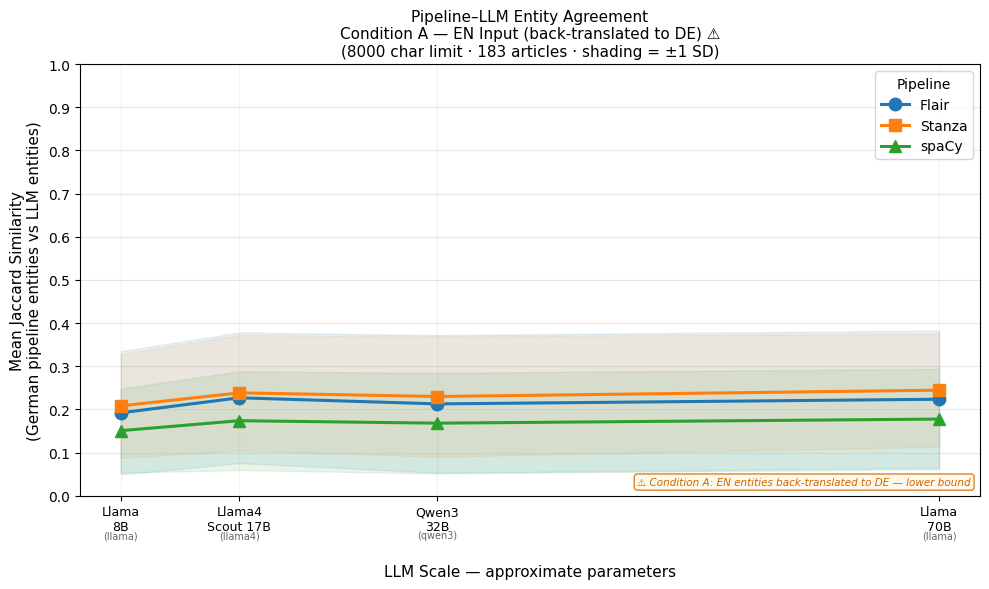

✓ Figure saved: nb13b_scaling_en.pdf/.png


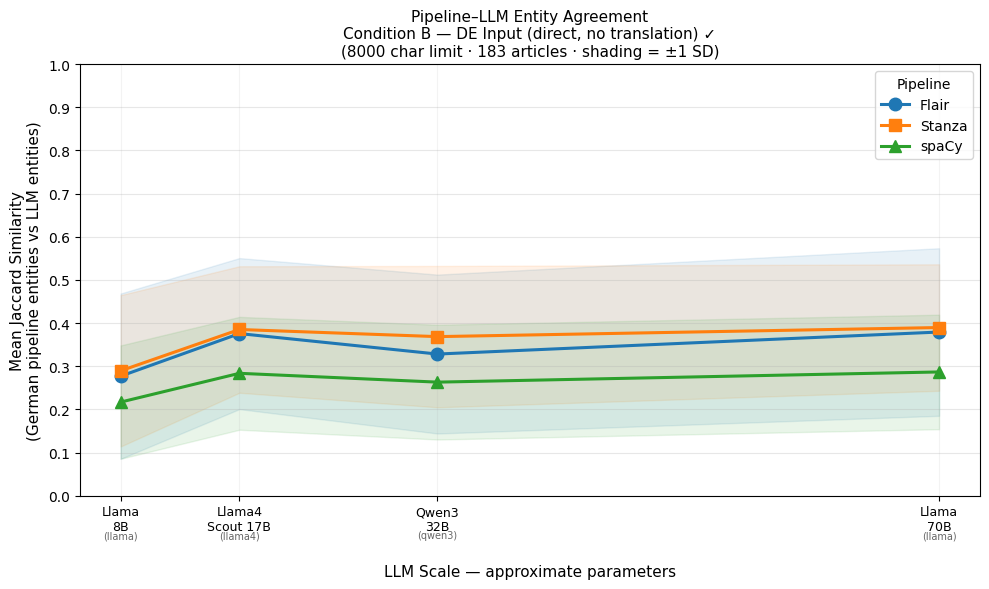

✓ Figure saved: nb13b_scaling_de.pdf/.png


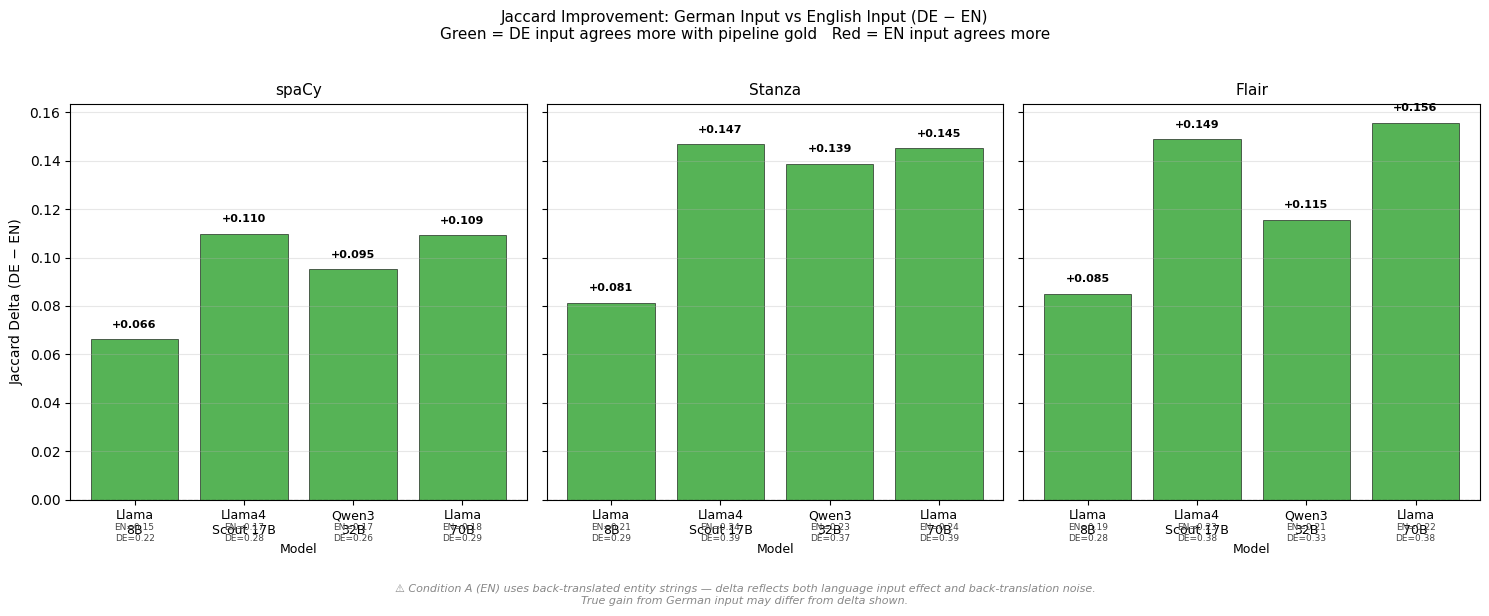

✓ Figure saved: nb13b_delta_de_en.pdf/.png

Delta summary (Flair pipeline — primary comparison):
                                    model  scale_B  en_mean  de_mean  delta
                     llama-3.1-8b-instant        8    0.192    0.277  0.085
meta-llama/llama-4-scout-17b-16e-instruct       17    0.227    0.376  0.149
                           qwen/qwen3-32b       32    0.213    0.328  0.115
                  llama-3.3-70b-versatile       70    0.224    0.379  0.156

Note: EN Jaccard uses back-translated entities — treat as lower bound for Condition A.


In [12]:
# ── CELL 11 : PLOTS ──────────────────────────────────────────────────────────
# All comparisons are now in German on both sides:
#   Condition A: pipeline (DE) vs LLM EN-input back-translated to DE  ⚠ lower bound
#   Condition B: pipeline (DE) vs LLM DE-input directly               ✓ clean

COND_LABELS = {
    'en': 'Condition A — EN Input (back-translated to DE) ⚠',
    'de': 'Condition B — DE Input (direct, no translation) ✓',
}

PIPELINE_STYLES = {
    'Flair' : {'color': '#1f77b4', 'marker': 'o', 'lw': 2.2, 'ms': 9},
    'Stanza': {'color': '#ff7f0e', 'marker': 's', 'lw': 2.2, 'ms': 9},
    'spaCy' : {'color': '#2ca02c', 'marker': '^', 'lw': 2.2, 'ms': 9},
}

def scale_xlabel(model_id, scale_B):
    s = int(scale_B)
    if 'llama-4'  in model_id.lower(): return f"Llama4\nScout {s}B"  # ← add this
    if 'qwen3'    in model_id.lower(): return f"Qwen3\n{s}B"
    if 'qwen2'    in model_id.lower(): return f"Qwen2.5\n{s}B"
    if '8b'       in model_id.lower(): return f"Llama\n{s}B"
    if '70b'      in model_id.lower(): return f"Llama\n{s}B"
    return f"{s}B"

model_order = sorted(model_meta.keys(),
                     key=lambda m: model_meta[m].get('scale_B', 0))

# ── Figures 1 & 2 : Scaling curves — one per condition ───────────────────────
for cond in ['en', 'de']:
    sub = jdf[jdf['condition'] == cond]
    if sub.empty:
        print(f"  No data for condition '{cond}' — skipping"); continue

    fig, ax = plt.subplots(figsize=(10, 6))

    for pname, style in PIPELINE_STYLES.items():
        psub = sub[sub['pipeline'] == pname].sort_values('scale_B')
        if psub.empty:
            continue
        ax.plot(psub['scale_B'], psub['mean'],
                label=pname,
                color=style['color'], marker=style['marker'],
                linewidth=style['lw'], markersize=style['ms'], zorder=3)
        ax.fill_between(psub['scale_B'],
                        psub['mean'] - psub['std'],
                        psub['mean'] + psub['std'],
                        alpha=0.1, color=style['color'])

    # x-axis ticks
    scale_rows = sub.drop_duplicates('scale_B').sort_values('scale_B')
    ax.set_xticks(scale_rows['scale_B'].tolist())
    ax.set_xticklabels(
        [scale_xlabel(r['model'], r['scale_B']) for _, r in scale_rows.iterrows()],
        fontsize=9)

    # Family annotation below x-axis
    for _, r in scale_rows.iterrows():
        family = model_meta.get(r['model'], {}).get('family', '')
        ax.annotate(f"({family})",
                    xy=(r['scale_B'], -0.08),
                    xycoords=('data', 'axes fraction'),
                    ha='center', va='top', fontsize=7, color='#666666')

    ax.set_xlabel('LLM Scale — approximate parameters', fontsize=11, labelpad=22)
    ax.set_ylabel('Mean Jaccard Similarity\n(German pipeline entities vs LLM entities)',
                  fontsize=11)
    ax.set_title(
        f'Pipeline–LLM Entity Agreement\n{COND_LABELS[cond]}\n'
        f'(8000 char limit · 183 articles · shading = ±1 SD)',
        fontsize=11)
    ax.legend(title='Pipeline', fontsize=10)
    ax.set_ylim(0, 1)
    ax.yaxis.set_major_locator(ticker.MultipleLocator(0.1))
    ax.grid(axis='y', alpha=0.3)
    ax.grid(axis='x', alpha=0.15)

    # Watermark for Condition A
    if cond == 'en':
        ax.text(0.99, 0.02,
                '⚠ Condition A: EN entities back-translated to DE — lower bound',
                transform=ax.transAxes, fontsize=7.5, color='#cc6600',
                ha='right', va='bottom', style='italic',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='#fff8e7',
                          edgecolor='#cc6600', alpha=0.8))

    plt.tight_layout()
    for ext in ['pdf', 'png']:
        fig.savefig(FIGURES_DIR / f'nb13b_scaling_{cond}.{ext}',
                    dpi=300 if ext == 'pdf' else 150, bbox_inches='tight')
    plt.show()
    print(f"✓ Figure saved: nb13b_scaling_{cond}.pdf/.png")


# ── Figure 3 : EN vs DE delta per model (main finding) ───────────────────────
# DE Jaccard minus EN Jaccard = gain from German input
# Positive = DE input agrees more with German pipeline gold
# Note: EN baseline includes back-translation noise — delta is upper bound on true gain

delta_records = []
for model_id in model_order:
    for pname in pipeline_lookups.keys():
        en_row = jdf[(jdf['model'] == model_id) &
                     (jdf['condition'] == 'en') &
                     (jdf['pipeline'] == pname)]
        de_row = jdf[(jdf['model'] == model_id) &
                     (jdf['condition'] == 'de') &
                     (jdf['pipeline'] == pname)]
        if en_row.empty or de_row.empty:
            continue
        delta_records.append({
            'model'    : model_id,
            'pipeline' : pname,
            'scale_B'  : model_meta[model_id]['scale_B'],
            'en_mean'  : float(en_row['mean'].values[0]),
            'de_mean'  : float(de_row['mean'].values[0]),
            'delta'    : float(de_row['mean'].values[0]) - float(en_row['mean'].values[0]),
        })

delta_df = pd.DataFrame(delta_records)

if not delta_df.empty:
    pipelines_to_plot = [p for p in ['spaCy', 'Stanza', 'Flair']
                         if p in delta_df['pipeline'].unique()]
    n_panels = len(pipelines_to_plot)

    fig, axes = plt.subplots(1, n_panels, figsize=(5 * n_panels, 5.5), sharey=True)
    if n_panels == 1:
        axes = [axes]

    models_sorted = sorted(delta_df['model'].unique(),
                           key=lambda m: model_meta[m]['scale_B'])

    for ax, pname in zip(axes, pipelines_to_plot):
        psub = (delta_df[delta_df['pipeline'] == pname]
                .set_index('model')
                .reindex(models_sorted)
                .reset_index())

        labels = [scale_xlabel(r['model'], r['scale_B'])
                  for _, r in psub.iterrows()]
        x      = np.arange(len(labels))
        colors = ['#2ca02c' if d > 0 else '#d62728' for d in psub['delta']]

        bars = ax.bar(x, psub['delta'], color=colors, alpha=0.8,
                      edgecolor='black', linewidth=0.5)
        ax.axhline(0, color='black', linewidth=0.8, linestyle='--')

        ax.set_xticks(x)
        ax.set_xticklabels(labels, fontsize=9)
        ax.set_title(f'{pname}', fontsize=11)
        ax.set_xlabel('Model', fontsize=9)
        ax.grid(axis='y', alpha=0.3)

        if ax == axes[0]:
            ax.set_ylabel('Jaccard Delta (DE − EN)', fontsize=10)

        # Value labels on bars
        for bar, val in zip(bars, psub['delta']):
            if np.isnan(val):
                continue
            ypos = bar.get_height() + (0.004 if val >= 0 else -0.010)
            ax.text(bar.get_x() + bar.get_width() / 2,
                    ypos, f'{val:+.3f}',
                    ha='center', va='bottom', fontsize=8, fontweight='bold')

        # EN/DE values as small text below each bar
        for xi, (_, row) in zip(x, psub.iterrows()):
            if np.isnan(row['en_mean']) or np.isnan(row['de_mean']):
                continue
            ax.text(xi, -0.06,
                    f"EN={row['en_mean']:.2f}\nDE={row['de_mean']:.2f}",
                    ha='center', va='top', fontsize=6.5,
                    color='#444444', transform=ax.get_xaxis_transform())

    fig.suptitle(
        'Jaccard Improvement: German Input vs English Input (DE − EN)\n'
        'Green = DE input agrees more with pipeline gold   '
        'Red = EN input agrees more',
        fontsize=11, y=1.02)

    # Limitation footnote
    fig.text(0.5, -0.06,
             '⚠ Condition A (EN) uses back-translated entity strings — '
             'delta reflects both language input effect and back-translation noise.\n'
             'True gain from German input may differ from delta shown.',
             ha='center', fontsize=8, color='#888888', style='italic')

    plt.tight_layout()
    for ext in ['pdf', 'png']:
        fig.savefig(FIGURES_DIR / f'nb13b_delta_de_en.{ext}',
                    dpi=300 if ext == 'pdf' else 150, bbox_inches='tight')
    plt.show()
    print("✓ Figure saved: nb13b_delta_de_en.pdf/.png")

    # Print delta table
    print("\nDelta summary (Flair pipeline — primary comparison):")
    flair_delta = (delta_df[delta_df['pipeline'] == 'Flair']
                   [['model', 'scale_B', 'en_mean', 'de_mean', 'delta']]
                   .sort_values('scale_B')
                   .copy())
    flair_delta[['en_mean', 'de_mean', 'delta']] = \
        flair_delta[['en_mean', 'de_mean', 'delta']].round(3)
    print(flair_delta.to_string(index=False))

    print("\nNote: EN Jaccard uses back-translated entities — "
          "treat as lower bound for Condition A.")
else:
    print("⚠ No paired EN+DE results available — delta plot skipped.")
    print("  Ensure both conditions completed in Cell 8.")

In [13]:
# ── CELL 12 : SAVE SUMMARY JSON ──────────────────────────────────────────────

run_status = {
    f"{mid}_{cond}": {
        'n_ok'       : len([r for r in ckpt['results'] if r['status']=='ok']),
        'n_failed'   : len(ckpt['failed_ids']),
        'stop_reason': ckpt.get('stop_reason'),
        'text_limit' : TEXT_LIMIT,
    }
    for (mid, cond), ckpt in all_results.items()
}

# Main finding: DE-EN delta for Flair pipeline
flair_delta_dict = {}
if not delta_df.empty:
    for _, row in delta_df[delta_df['pipeline']=='Flair'].iterrows():
        flair_delta_dict[row['model']] = {
            'en_jaccard' : round(row['en_mean'], 4),
            'de_jaccard' : round(row['de_mean'], 4),
            'delta'      : round(row['delta'], 4),
        }

summary = {
    'notebook'       : '13b_en_de_comparison',
    'generated_at'   : datetime.now().isoformat(),
    'n_articles'     : len(ARTICLE_IDS_183),
    'text_limit'     : TEXT_LIMIT,
    'conditions'     : {
        'en': 'English translation input — entity output in English',
        'de': 'German original input — entity output in German (no translation)',
    },
    'models'         : {mid: meta for mid, meta in model_meta.items()},
    'jaccard_full'   : {
        f"{r['pipeline']}|{r['model']}|{r['condition']}": round(r['mean'],4)
        for _,r in jdf.iterrows()
    },
    'de_en_delta_flair': flair_delta_dict,
    'run_status'     : run_status,
    'notes': (
    'All runs at 8000 char text limit (96.6% entity coverage by position). '
    'Condition A (EN input): LLM English entity strings back-translated EN→DE '
    'via OPUS-MT before Jaccard — conservative lower bound due to surface form '
    'mismatches after isolated-string translation. '
    'Condition B (DE input): LLM German entity strings compared directly to '
    'pipeline gold — methodologically clean comparison. '
    'DE prompt includes explicit "do not translate" instruction. '
    'Qwen 7B uses HuggingFace Inference API; skipped if all providers exhausted.'
),
}

with open(DATA_PROC / 'nb13b_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print("="*64)
print("NOTEBOOK 13b COMPLETE")
print("="*64)
print("  nb13b_jaccard_results.csv   — full Jaccard matrix")
print("  nb13b_summary.json          — summary + DE-EN delta")
print("  nb13b_scaling_en.pdf/.png   — scaling curve (EN input)")
print("  nb13b_scaling_de.pdf/.png   — scaling curve (DE input)")
print("  nb13b_delta_de_en.pdf/.png  — EN→DE improvement per model")
print()
print("DE-EN Jaccard delta (Flair pipeline — main finding):")
for model, vals in flair_delta_dict.items():
    scale = model_meta.get(model,{}).get('scale_B','?')
    print(f"  {model:<40} {scale}B  "
          f"EN={vals['en_jaccard']:.3f}  DE={vals['de_jaccard']:.3f}  "
          f"delta={vals['delta']:+.3f}")


NOTEBOOK 13b COMPLETE
  nb13b_jaccard_results.csv   — full Jaccard matrix
  nb13b_summary.json          — summary + DE-EN delta
  nb13b_scaling_en.pdf/.png   — scaling curve (EN input)
  nb13b_scaling_de.pdf/.png   — scaling curve (DE input)
  nb13b_delta_de_en.pdf/.png  — EN→DE improvement per model

DE-EN Jaccard delta (Flair pipeline — main finding):
  llama-3.1-8b-instant                     8B  EN=0.192  DE=0.277  delta=+0.085
  meta-llama/llama-4-scout-17b-16e-instruct 17B  EN=0.227  DE=0.376  delta=+0.149
  qwen/qwen3-32b                           32B  EN=0.213  DE=0.328  delta=+0.116
  llama-3.3-70b-versatile                  70B  EN=0.224  DE=0.379  delta=+0.156


In [ ]:
# ── ISSUE 2 DIAGNOSTIC — Back-translation effect on EN Jaccard ───────────────
# Compares: raw EN entities vs pipeline gold (text match only)
#       vs: translated EN entities vs pipeline gold (text match only)
# Shows exactly how much back-translation helped or hurt

import pickle
import numpy as np
from pathlib import Path

DATA_PROC = Path('/content/drive/MyDrive/thesis/Project/Data/Processed')

# Load Llama 8B EN checkpoint (raw English entities)
print("Loading Llama 8B EN entities...")
with open(DATA_PROC / 'nb13b_llama-3_1-8b-instant_en_8k_checkpoint.pkl', 'rb') as f:
    en_ckpt = pickle.load(f)

# Load translation cache
print("Loading translation cache...")
cache_path = DATA_PROC / 'nb13b_translated_en_lookups.pkl'
if not cache_path.exists():
    print("  ⚠ Translation cache not found — run Cell 9 first")
else:
    with open(cache_path, 'rb') as f:
        translated_lookups = pickle.load(f)

    # Get Llama 8B EN translated lookup
    llama8b_key = ('llama-3.1-8b-instant', 'en')
    translated_lookup = translated_lookups.get(llama8b_key, {})

    # Build raw EN lookup (before translation, text only)
    raw_lookup = {}
    for r in en_ckpt['results']:
        if r.get('status') == 'ok':
            raw_lookup[r['article_id']] = {
                e.get('text','').lower()
                for e in r.get('entities', [])
                if isinstance(e, dict)
            }

    # Build translated EN lookup (text only, after translation)
    trans_lookup = {}
    for aid, ents in translated_lookup.items():
        trans_lookup[aid] = {text for text, label in ents}

    # Load pipeline gold (Flair — text only)
    pipeline_df_loaded = pd.read_pickle(DATA_PROC / 'ner_pipeline_results.pkl')
    flair_lookup = {}
    for _, row in pipeline_df_loaded.iterrows():
        aid = row['article_id']
        raw = row.get('ner_flair', [])
        if isinstance(raw, list):
            flair_lookup[aid] = {
                e.get('text','').lower()
                for e in raw if isinstance(e, dict)
            }

    # Compute text-only Jaccard (ignoring labels) for raw and translated
    def jaccard_text(a, b):
        if not a and not b: return 1.0
        if not a or not b: return 0.0
        return len(a & b) / len(a | b)

    article_ids = list(raw_lookup.keys())
    raw_jaccards   = []
    trans_jaccards = []
    changed_counts = []

    for aid in article_ids:
        flair_ents = flair_lookup.get(aid, set())
        raw_ents   = raw_lookup.get(aid, set())
        trans_ents = trans_lookup.get(aid, set())

        raw_jaccards.append(jaccard_text(flair_ents, raw_ents))
        trans_jaccards.append(jaccard_text(flair_ents, trans_ents))

        # Count how many strings actually changed after translation
        changed = sum(1 for t in trans_ents if t not in raw_ents)
        changed_counts.append(changed)

    print(f"\n{'='*60}")
    print("BACK-TRANSLATION EFFECT (Flair pipeline, Llama 8B EN)")
    print(f"{'='*60}")
    print(f"  Articles compared    : {len(article_ids)}")
    print(f"\n  Text-only Jaccard (no label matching):")
    print(f"    Raw EN entities    : {np.mean(raw_jaccards):.4f}")
    print(f"    Translated EN→DE   : {np.mean(trans_jaccards):.4f}")
    print(f"    Delta              : {np.mean(trans_jaccards)-np.mean(raw_jaccards):+.4f}")
    print(f"\n  Per-article strings changed by translation:")
    print(f"    Mean changed/art   : {np.mean(changed_counts):.1f}")
    print(f"    Max changed/art    : {max(changed_counts)}")
    print(f"    Articles 0 changed : {sum(1 for c in changed_counts if c==0)}")

    # Show actual translations for first article
    print(f"\n  Sample — ART_0000:")
    first_art = article_ids[0]
    raw_e   = raw_lookup.get(first_art, set())
    trans_e = trans_lookup.get(first_art, set())
    flair_e = flair_lookup.get(first_art, set())
    print(f"    Flair gold  : {sorted(flair_e)[:8]}")
    print(f"    Raw EN ents : {sorted(raw_e)[:8]}")
    print(f"    Translated  : {sorted(trans_e)[:8]}")
    print(f"    Matches (raw)  : {sorted(flair_e & raw_e)}")
    print(f"    Matches (trans): {sorted(flair_e & trans_e)}")

    # Check specific translations
    print(f"\n  Checking key translations:")
    check_pairs = [
        ('germany', 'deutschland'),
        ('munich', 'münchen'),
        ('federal government', 'bundesregierung'),
        ('rhineland', 'rheinland'),
        ('austria', 'österreich'),
        ('european union', 'europäische union'),
    ]
    # Build full translation map from all lookups
    full_trans_map = {}
    for aid, ents in translated_lookup.items():
        for text, label in ents:
            # find original in raw
            raw_ents_art = {e.get('text','').lower()
                           for e in en_ckpt['results'][0].get('entities',[])
                           if isinstance(e, dict)}
    # Reconstruct map from raw vs translated
    for aid in list(article_ids)[:20]:
        raw_set   = raw_lookup.get(aid, set())
        trans_set = trans_lookup.get(aid, set())
        for en_t in raw_set:
            # Find what it became (look for similar length string in trans)
            pass  # approximation below

    # Just check if target strings appear in translated lookups
    all_trans_texts = {text for ents in translated_lookup.values()
                       for text, _ in ents}
    for en_word, de_word in check_pairs:
        en_present   = any(en_word in t for t in all_trans_texts)
        de_present   = any(de_word in t for t in all_trans_texts)
        if de_present:
            print(f"    ✓ '{de_word}' present in translated output")
        elif en_present:
            print(f"    ✗ '{en_word}' NOT translated to '{de_word}'")
        else:
            print(f"    – '{en_word}' not in entity set at all")

Loading Llama 8B EN entities...
Loading translation cache...

BACK-TRANSLATION EFFECT (Flair pipeline, Llama 8B EN)
  Articles compared    : 183

  Text-only Jaccard (no label matching):
    Raw EN entities    : 0.2797
    Translated EN→DE   : 0.2148
    Delta              : -0.0649

  Per-article strings changed by translation:
    Mean changed/art   : 8.2
    Max changed/art    : 32
    Articles 0 changed : 14

  Sample — ART_0000:
    Flair gold  : ['basf', 'deutschland', 'gladbeck', 'hawaii', 'rheinland', 'volker christmann']
    Raw EN ents : ['basf', 'december', 'eps', 'federal government', 'germany', 'gladbeck', 'hawaii', 'rhineland']
    Translated  : ['basf', 'bund', 'deutschland', 'dezember', 'eps', 'gladbeck', 'hawaii', 'rheinland']
    Matches (raw)  : ['basf', 'gladbeck', 'hawaii', 'volker christmann']
    Matches (trans): ['basf', 'deutschland', 'gladbeck', 'hawaii', 'rheinland', 'volker christmann']

  Checking key translations:
    ✓ 'deutschland' present in translated 

In [ ]:
# ── PRE-RERUN AUDIT ───────────────────────────────────────────────────────────
import pickle, json, numpy as np, pandas as pd
from pathlib import Path

DATA_PROC = Path('/content/drive/MyDrive/thesis/Project/Data/Processed')

# ── 1. Jaccard sanity checks ──────────────────────────────────────────────────
print("=" * 60)
print("1. JACCARD RESULTS SANITY CHECK")
print("=" * 60)
jdf = pd.read_csv(DATA_PROC / 'nb13b_jaccard_results.csv')
print(f"Shape: {jdf.shape}")
print(f"Columns: {list(jdf.columns)}")
print(f"\nNaN values:\n{jdf.isnull().sum()}")
print(f"\nArticle counts per model+condition:")
print(jdf.groupby(['model','condition'])['n'].first().to_string())
print(f"\nFlair Jaccard means (should be highest pipeline):")
print(jdf[jdf['pipeline']=='Flair'][['model','condition','mean','n']]
      .sort_values(['model','condition']).to_string(index=False))

# ── 2. Delta computation check ────────────────────────────────────────────────
print("\n" + "=" * 60)
print("2. DELTA COMPUTATION — are EN and DE using same article sets?")
print("=" * 60)
for model in jdf['model'].unique():
    en = jdf[(jdf['model']==model)&(jdf['condition']=='en')&(jdf['pipeline']=='Flair')]
    de = jdf[(jdf['model']==model)&(jdf['condition']=='de')&(jdf['pipeline']=='Flair')]
    if en.empty or de.empty:
        print(f"  {model}: EN={not en.empty} DE={not de.empty} — MISSING ONE CONDITION")
        continue
    n_en = int(en['n'].values[0])
    n_de = int(de['n'].values[0])
    match = "✓" if n_en == n_de else "⚠ MISMATCH"
    print(f"  {model}: EN n={n_en}  DE n={n_de}  {match}")

# ── 3. Llama 8B DE — language check ──────────────────────────────────────────
print("\n" + "=" * 60)
print("3. LLAMA 8B DE — entity language verification")
print("=" * 60)
fp = DATA_PROC / 'nb13b_llama-3_1-8b-instant_de_8k_checkpoint.pkl'
if fp.exists():
    with open(fp, 'rb') as f:
        ckpt = pickle.load(f)
    results = [r for r in ckpt['results'] if r.get('status') == 'ok']
    print(f"  Articles: {len(results)}")

    # Sample entities from first 5 articles
    print("\n  First 5 articles — entity samples:")
    for r in results[:5]:
        ents = [e.get('text','') for e in r.get('entities',[])[:4]
                if isinstance(e,dict)]
        print(f"  {r['article_id']}: {ents}")

    # Language signal check
    all_texts = [e.get('text','').lower()
                 for r in results for e in r.get('entities',[])
                 if isinstance(e,dict)]
    en_signals = ['germany','munich','cologne','austria','france',
                  'federal government','european union','switzerland']
    de_signals = ['deutschland','münchen','köln','österreich','frankreich',
                  'bundesregierung','europäische union','schweiz']
    en_hits = sum(1 for t in all_texts if any(s in t for s in en_signals))
    de_hits = sum(1 for t in all_texts if any(s in t for s in de_signals))
    print(f"\n  Total entities : {len(all_texts)}")
    print(f"  English signals: {en_hits} ({en_hits/len(all_texts)*100:.1f}%)")
    print(f"  German signals : {de_hits} ({de_hits/len(all_texts)*100:.1f}%)")
    print(f"  Verdict: {'GERMAN ✓' if de_hits > en_hits else 'ENGLISH ⚠' if en_hits > de_hits else 'NEUTRAL (names/acronyms dominate)'}")

    # Empty entity articles
    empty = sum(1 for r in results if r.get('entities') == [])
    print(f"  Empty entity articles: {empty}")
else:
    print("  File not found")

# ── 4. Llama 8B EN — volume check at 8000 vs old 3000 chars ──────────────────
print("\n" + "=" * 60)
print("4. LLAMA 8B EN — entity volume at 8000 chars vs old 3000 chars")
print("=" * 60)
fp_new = DATA_PROC / 'nb13b_llama-3_1-8b-instant_en_8k_checkpoint.pkl'
fp_old = DATA_PROC / 'nb13_llama-3.1-8b-instant_checkpoint.pkl'

for label, fp in [('NEW 8k', fp_new), ('OLD 3k', fp_old)]:
    if not fp.exists():
        print(f"  {label}: not found"); continue
    with open(fp, 'rb') as f:
        ckpt = pickle.load(f)
    results = [r for r in ckpt['results'] if r.get('status')=='ok']
    counts  = [len(r.get('entities',[])) for r in results]
    print(f"\n  {label}:")
    print(f"    Articles      : {len(counts)}")
    print(f"    Total entities: {sum(counts)}")
    print(f"    Mean per art  : {np.mean(counts):.1f}")
    print(f"    Median        : {np.median(counts):.1f}")
    print(f"    Zero-ent arts : {sum(1 for c in counts if c==0)}")

# ── 5. Back-translation spot check ───────────────────────────────────────────
print("\n" + "=" * 60)
print("5. BACK-TRANSLATION SPOT CHECK")
print("=" * 60)
print("Loading OPUS-MT and testing on Llama 8B EN entities...")
fp = DATA_PROC / 'nb13b_llama-3_1-8b-instant_en_8k_checkpoint.pkl'
if fp.exists():
    with open(fp, 'rb') as f:
        ckpt = pickle.load(f)
    # Get first 30 unique entity texts
    seen, sample = set(), []
    for r in ckpt['results']:
        for e in r.get('entities',[]):
            if isinstance(e,dict):
                t = e.get('text','').strip()
                if t and t not in seen:
                    seen.add(t); sample.append(t)
        if len(sample) >= 30: break
    sample = sample[:30]

    try:
        from easynmt import EasyNMT
        mt = EasyNMT('opus-mt')
        translations = mt.translate(sample, source_lang='en', target_lang='de')
        print(f"\n  {'EN entity':<35} {'DE translation':<35} {'Changed?'}")
        print(f"  {'-'*35} {'-'*35} {'-'*8}")
        for en, de in zip(sample, translations):
            changed = "yes" if en.lower() != de.lower() else "same"
            marker  = "⚠" if changed == "same" and len(en) > 3 else " "
            print(f"  {marker} {en:<34} {de:<34} {changed}")
    except Exception as ex:
        print(f"  Could not load OPUS-MT: {ex}")
else:
    print("  Llama 8B EN 8k checkpoint not found")

# ── 6. Qwen 7B status check ───────────────────────────────────────────────────
print("\n" + "=" * 60)
print("6. QWEN 7B STATUS")
print("=" * 60)
for cond in ['en','de']:
    safe = 'Qwen_Qwen2_5-7B-Instruct'
    fp   = DATA_PROC / f'nb13b_{safe}_{cond}_8k_checkpoint.pkl'
    if fp.exists():
        with open(fp,'rb') as f: ckpt = pickle.load(f)
        n_ok = len([r for r in ckpt['results'] if r.get('status')=='ok'])
        print(f"  [{cond.upper()}] stop={ckpt.get('stop_reason')}  "
              f"ok={n_ok}  failed={len(ckpt.get('failed_ids',[]))}")
    else:
        print(f"  [{cond.upper()}] checkpoint not found")

1. JACCARD RESULTS SANITY CHECK
Shape: (24, 9)
Columns: ['pipeline', 'model', 'condition', 'scale_B', 'family', 'mean', 'std', 'median', 'n']

NaN values:
pipeline     0
model        0
condition    0
scale_B      0
family       0
mean         0
std          0
median       0
n            0
dtype: int64

Article counts per model+condition:
model                     condition
Qwen/Qwen2.5-7B-Instruct  de             4
                          en           172
llama-3.1-8b-instant      de           182
                          en           183
llama-3.3-70b-versatile   de            50
                          en           178
qwen/qwen3-32b            de           180
                          en           183

Flair Jaccard means (should be highest pipeline):
                   model condition     mean   n
Qwen/Qwen2.5-7B-Instruct        de 0.173913   4
Qwen/Qwen2.5-7B-Instruct        en 0.200502 172
    llama-3.1-8b-instant        de 0.276996 182
    llama-3.1-8b-instant        en 0.

In [14]:
# ── LLM AGREEMENT THRESHOLD CHECK ────────────────────────────────────────────
# Shows how many gold entities you get at different agreement levels
# Run after Llama 70B DE is complete

import pickle
from pathlib import Path
from collections import defaultdict

DATA_PROC = Path('/content/drive/MyDrive/thesis/Project/Data/Processed')

DE_CHECKPOINTS = {
    'llama-3.1-8b-instant'                     : 'nb13b_llama-3_1-8b-instant_de_8k_checkpoint.pkl',
    'llama-4-scout-17b-16e-instruct'           : 'nb13b_meta-llama_llama-4-scout-17b-16e-instruct_de_8k_checkpoint.pkl',
    'qwen/qwen3-32b'                           : 'nb13b_qwen_qwen3-32b_de_8k_checkpoint.pkl',
    'llama-3.3-70b-versatile'                  : 'nb13b_llama-3_3-70b-versatile_de_8k_checkpoint.pkl',
}

LABEL_NORM = {
    "PERSON":"PER","person":"PER",
    "LOCATION":"LOC","location":"LOC","GPE":"LOC","FAC":"LOC",
    "ORGANIZATION":"ORG","organisation":"ORG","organization":"ORG",
    "MISCELLANEOUS":"MISC","miscellaneous":"MISC",
    "EVENT":"MISC","PRODUCT":"MISC","NORP":"MISC","DATE":"MISC",
    "PER":"PER","LOC":"LOC","ORG":"ORG","MISC":"MISC",
}
VALID_LABELS = {"PER","LOC","ORG","MISC"}

def normalize(entity_list):
    out = set()
    for e in (entity_list or []):
        if isinstance(e, dict):
            text  = str(e.get('text','')).strip().lower()
            label = LABEL_NORM.get(str(e.get('label','')), None)
            if text and label in VALID_LABELS:
                out.add((text, label))
    return out

# Load all DE checkpoints
llm_de_lookups = {}
for name, fname in DE_CHECKPOINTS.items():
    fp = DATA_PROC / fname
    if not fp.exists():
        print(f"  ⚠ NOT FOUND: {fname}")
        continue
    with open(fp, 'rb') as f:
        ckpt = pickle.load(f)
    lookup = {r['article_id']: normalize(r.get('entities',[]))
              for r in ckpt.get('results',[]) if r.get('status')=='ok'}
    llm_de_lookups[name] = lookup
    print(f"  ✓ {name}: {len(lookup)} articles")

# Find articles present in ALL loaded models
all_article_sets = [set(v.keys()) for v in llm_de_lookups.values()]
shared_articles  = set.intersection(*all_article_sets) if all_article_sets else set()
print(f"\n  Shared articles across all DE models: {len(shared_articles)}")

# Count entities per agreement level
n_models = len(llm_de_lookups)
print(f"\n  Agreement threshold analysis ({n_models} models):")
print(f"  {'Threshold':<25} {'Total entities':>15} {'Mean/article':>13}")
print(f"  {'-'*55}")

for threshold in range(1, n_models + 1):
    total_ents = 0
    for aid in shared_articles:
        # Count how many models found each entity
        entity_counts = defaultdict(int)
        for model_lookup in llm_de_lookups.values():
            for ent in model_lookup.get(aid, set()):
                entity_counts[ent] += 1
        # Keep entities found by >= threshold models
        agreed = {e for e, c in entity_counts.items() if c >= threshold}
        total_ents += len(agreed)

    mean_per_art = total_ents / len(shared_articles) if shared_articles else 0
    label = ('(any model)' if threshold == 1
             else '(majority)' if threshold == n_models // 2 + 1
             else '(full agreement)' if threshold == n_models
             else '')
    print(f"  {threshold}/{n_models} models agree  {label:<12} "
          f"{total_ents:>15,}  {mean_per_art:>12.1f}")

# Compare to pipeline gold
print(f"\n  Pipeline gold for reference:")
print(f"  Full spaCy+Stanza+Flair agreement: 1,311 entities across 183 articles")
print(f"  Mean per article: ~7.2")

  ✓ llama-3.1-8b-instant: 182 articles
  ✓ llama-4-scout-17b-16e-instruct: 181 articles
  ✓ qwen/qwen3-32b: 180 articles
  ✓ llama-3.3-70b-versatile: 162 articles

  Shared articles across all DE models: 158

  Agreement threshold analysis (4 models):
  Threshold                  Total entities  Mean/article
  -------------------------------------------------------
  1/4 models agree  (any model)            5,107          32.3
  2/4 models agree                         2,730          17.3
  3/4 models agree  (majority)             1,994          12.6
  4/4 models agree  (full agreement)           1,224           7.7

  Pipeline gold for reference:
  Full spaCy+Stanza+Flair agreement: 1,311 entities across 183 articles
  Mean per article: ~7.2
